<a href="https://colab.research.google.com/github/joaovitor73/Machine-Learning/blob/Master/framework_para_series_temporais_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Darts: Framework para Series Temporais

**SEMINÁRIO DE APRENDIZADO DE MAQUINA**

| Detalhes | Informação |
| :--- | :--- |
| **Nome:** | João Vitor Gomes Vieira|
| **Curso:** | Analise e Desenvolvimento de Sistemas|
| **Professor:** | Josenalde Barbosa de Olibeira |
| **Data:** | 29/10/2025 |

---
**Declaração de Autorização:** Autorizo a disponibilização deste material no Instagram do TADS.

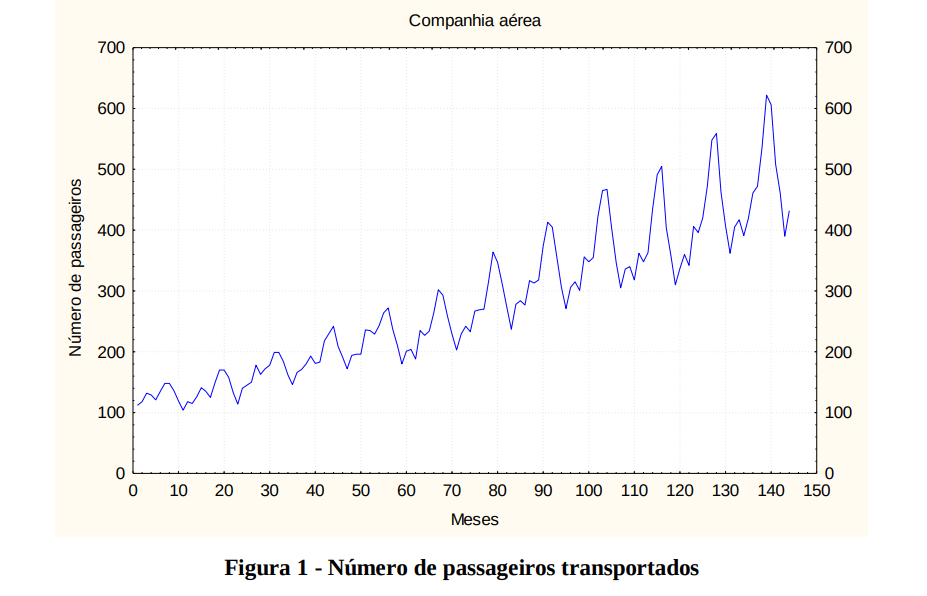

# 🕒 **Séries Temporais**

**Definição:**  
Sequência de observações registradas ao longo do tempo, onde **a ordem importa**.



---

## 🧩 **Análise dos Componentes da Série Temporal**

Abaixo é mostrado um **grid com quatro gráficos**, representando as diferentes partes que compõem a série temporal:

1️⃣ **Dados Reais:**  
Série original observada ao longo do tempo.  

2️⃣ **Tendência (T):**  
Mostra o movimento de longo prazo — crescimento, queda ou estabilidade.  

3️⃣ **Sazonalidade (S):**  
Evidencia os padrões cíclicos que se repetem em intervalos regulares.  

4️⃣ **Ruído (R):**  
Representa as variações aleatórias e imprevisíveis que não podem ser explicadas pelos outros componentes.  

---

🧠 *A decomposição da série ajuda a entender o comportamento dos dados e a construir modelos de previsão mais precisos.*


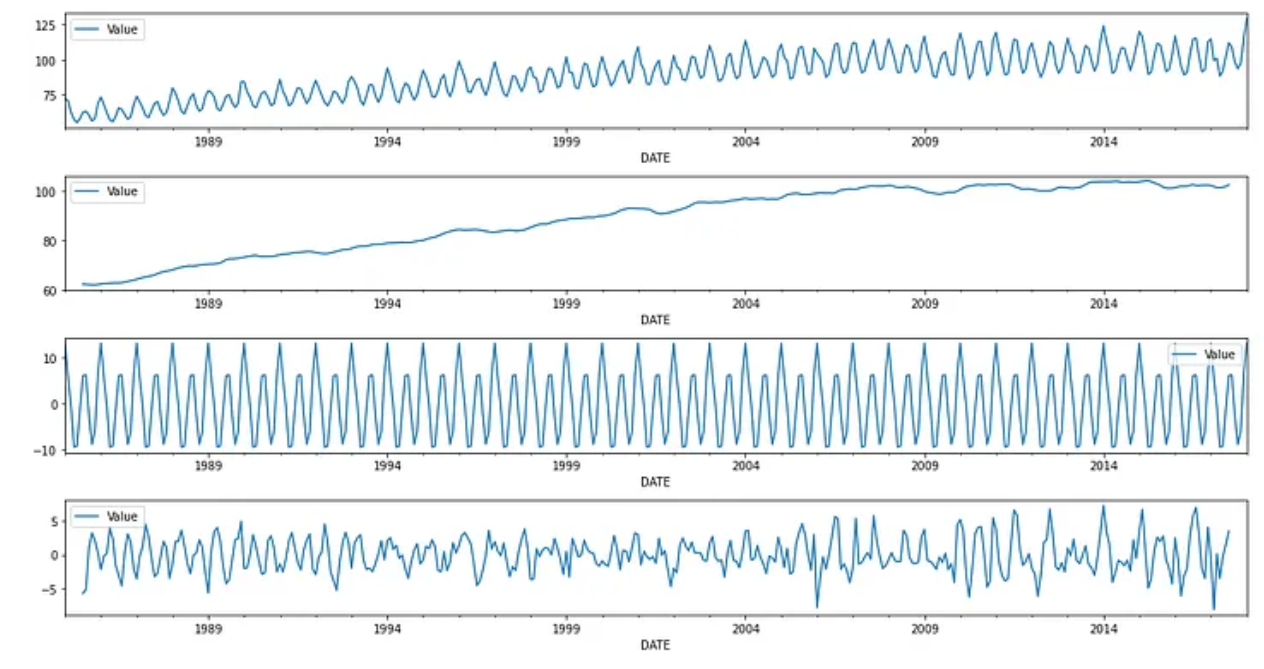

## 🌊 Estacionariedade em Séries Temporais

A **estacionariedade** Uma série temporal é considerada estacionária se suas propriedades estatísticas (como média, variância e autocorrelação) **não mudam ao longo do tempo**.

**Por que a estacionariedade é importante?**

Muitos modelos de séries temporais, especialmente os estatísticos como ARIMA, assumem que a série é estacionária para funcionar corretamente.

**Como lidar com a não estacionariedade?**

*   **Diferenciação:** Calcular a diferença entre observações consecutivas para remover a tendência.
*   **Transformações:** Aplicar funções matemáticas (como logaritmo) para estabilizar a variância.
*   **Remoção da sazonalidade:** Técnicas específicas para remover o componente sazonal.

Ao tornar uma série estacionária, podemos aplicar uma gama maior de modelos e obter previsões mais confiáveis.

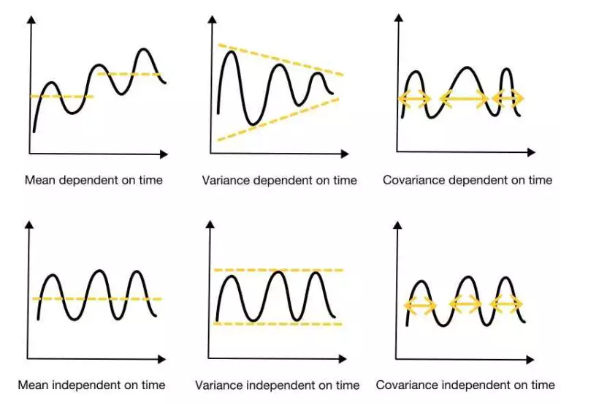

---

## 🆚 **Séries Temporais (ST) vs. Regressão Linear Clássica (RLC)**

| 🧩 **Característica** | 📈 **Séries Temporais (ST)** | 📊 **Regressão Linear Clássica (RLC)** |
| :---: | :--- | :--- |
| **Foco** | **Previsão (Extrapolação)** de valores futuros. | **Explicação (Interpolação)** das relações entre variáveis. |
| **Suposição Central** | As observações são **dependentes** no tempo. | As observações são **independentes** (I.I.D.). |
| **Tratamento da Ordem Temporal** | A **ordem** das observações carrega informação essencial. | A **ordem** das observações é irrelevante. |
| **Problema Típico** | Ignorar $T$ e $S$ gera **erros correlacionados** e previsões incorretas. | Ineficaz quando a **sequência temporal** é o fator principal. |

---

🧠 *Conclusão:*  
Modelos de regressão tradicional funcionam bem em dados estáticos,  
mas **séries temporais exigem técnicas próprias** que considerem dependência temporal, tendência e sazonalidade.


# 🧠 **2. Famílias de Modelos e o Papel do Darts**

## 📊 **Quando Usar Qual Modelo?**

| 🏷️ **Família** | 🧩 **Exemplos** | 🎯 **Cenário Ideal** | ⚡ **Vantagem Principal** |
| :---: | :--- | :--- | :--- |
| **📈 Estatísticos** | ARIMA, Exponential Smoothing, Prophet | Séries **curtas e bem comportadas**, com foco em **interpretabilidade** (T e S). | Alta interpretabilidade e simplicidade. |
| **🤖 Machine Learning (ML)** | XGBoost, Random Forest | Séries com **múltiplas variáveis (covariáveis)** e **relações não lineares**. | Excelente para **dados tabulares** e **engenharia de atributos**. |
| **🧬 Deep Learning (DL)** | N-BEATS, TCN, LSTM | Séries **longas, complexas e ruidosas**, aplicadas em **modelos globais**. | Captura **padrões complexos** e **dependências de longo prazo**. |

---

🧠 **Resumo:**  
O Darts permite integrar **todas essas famílias de modelos** em um único ambiente, facilitando a comparação, o empilhamento (ensemble) e a previsão de séries temporais de diferentes naturezas.



## 🎯 Darts: O Framework Unificador

O Darts é o **Scikit-learn para Séries Temporais**.
* **API Unificada:** Usa `.fit()` e `.predict()` para **TODOS** os modelos (do ARIMA ao N-BEATS).
* **Flexibilidade:** Permite comparar modelos de diferentes famílias (Estatístico vs. DL) na mesma base.
* **Backtesting:** Inclui ferramentas robustas para avaliação temporal (simulação de previsões históricas).

In [ ]:
import pandas as pd
from darts import TimeSeries
from darts.models import ExponentialSmoothing
import matplotlib.pyplot as plt
from darts.datasets import AirPassengersDataset # Import the dataset class

# Create a TimeSeries from the Darts dataset
series = AirPassengersDataset().load() # Load the dataset directly

# Set aside the last 36 months as a validation series
train, val = series[:-36], series[-36:]

model = ExponentialSmoothing()
model.fit(train)
prediction = model.predict(len(val), num_samples=1000)

series.plot()
prediction.plot(label="forecast", low_quantile=0.05, high_quantile=0.95)
plt.legend()

# 3. Métricas de Avaliação (Backtesting)

A avaliação deve ser feita em dados **não vistos** e de forma **temporalmente correta** (Backtesting).

| Métrica | Nome | Fórmula (Conceito) | Quando Usar |
| :---: | :--- | :--- | :--- |
| **RMSE** | Raiz do Erro Quadrático Médio | Penaliza erros **grandes** (ao elevar ao quadrado). | Quando erros grandes são inaceitáveis (ex.: previsão de risco). |
| **MAPE** | Erro Percentual Médio Absoluto | Erro em **percentual**, independente da escala dos dados. | Para comparar o desempenho de um modelo em múltiplas séries com escalas diferentes. |
| **MAE** | Erro Médio Absoluto | Média do desvio absoluto. Robusto a *outliers*. Dá uma visão intuitiva do erro médio. | Quando se quer uma métrica simples e interpretável, sem penalizar excessivamente grandes erros. |


# 4. Demonstração Darts: Setup e Preparação

In [ ]:
!pip install darts

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from darts import TimeSeries
from darts.datasets import MonthlyMilkDataset
from darts.models import ExponentialSmoothing, ARIMA, TCNModel
from darts.metrics import mape, rmse, mae
from statsmodels.tsa.seasonal import seasonal_decompose
import plotly.graph_objects as go
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from darts.models import LinearRegressionModel

In [ ]:
# 1. Carregar a série temporal (Monthly Milk Production)
series = MonthlyMilkDataset().load() # Load the new dataset

In [ ]:
# Visualização da Série (Mostrar Tendência e Sazonalidade)
plt.figure(figsize=(12, 4))
series.plot(label='Série Original (Monthly Milk Production)')
plt.title("Série Temporal: Dependência e Sazonalidade")
plt.show()

In [ ]:
# Convert Darts TimeSeries to pandas Series para mostrar decompor os dados
series_pandas = pd.Series(series.values().flatten(), index=series.time_index)

decomposition = seasonal_decompose(series_pandas, model='additive')

# Plot the decomposed components
plt.figure(figsize=(12, 8))
plt.subplot(411)
decomposition.observed.plot(label='Observado')
plt.legend()
plt.subplot(412)
decomposition.trend.plot(label='Tendencia')
plt.legend()
plt.subplot(413)
decomposition.seasonal.plot(label='Sasonalidade')
plt.legend()
plt.subplot(414)
decomposition.resid.plot(label='Residuo')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
series_pandas.head()

In [ ]:
# 2. Dividir em Treino e Teste (Backtesting)
TREINO_END = 0.8  # 80% para treino
train, val = series.split_before(TREINO_END)

print(f"Janela de Treino: {len(train)} observações")
print(f"Janela de Validação: {len(val)} observações")

forecast_horizon = len(val)

In [ ]:
# Inicializar dicionário para armazenar resultados
results = {}

# --- A. Modelo Estatístico: Exponential Smoothing (Clássico) ---
model_es = ExponentialSmoothing()
model_es.fit(train)
pred_es = model_es.predict(forecast_horizon)
results['ES'] = {'pred': pred_es, 'mape': mape(val, pred_es), 'rmse': rmse(val, pred_es), 'mae': mae(val, pred_es)}
#

# --- B. Modelo Estatístico: SARIMA (Para Estacionariedade e Sazonalidade) ---
# (1,1,1) x (0,1,0,12) são parâmetros comuns de partida para dados mensais.
model_arima = ARIMA(
    p=1, d=1, q=1, # Parte não sazonal
    seasonal_order=(0, 1, 0, 12), # Parte sazonal (Período de 12)
    random_state=42
)
model_arima.fit(train)
pred_arima = model_arima.predict(forecast_horizon)
results['ARIMA'] = {'pred': pred_arima, 'mape': mape(val, pred_arima), 'rmse' : rmse(val, pred_arima), 'mae' : mae(val, pred_arima)}

# --- C. Modelo Deep Learning: TCN (Temporal Convolutional Network) ---
# Modelo para padrões complexos e não-lineares.
input_chunk = 36 # Olhar para 3 anos anteriores
model_tcn = TCNModel(
    input_chunk_length=input_chunk,
    output_chunk_length=forecast_horizon,
    n_epochs=100,
    random_state=42
)
model_tcn.fit(train)
pred_tcn = model_tcn.predict(forecast_horizon)
results['TCN'] = {'pred': pred_tcn, 'mape': mape(val, pred_tcn), 'rmse' : rmse(val, pred_tcn), 'mae' : mae(val, pred_tcn)}


# --- D. Modelo Machine Learning: LinearRegressionModel ---

model_lr = LinearRegressionModel(lags=12) # Using 12 lags as features
model_lr.fit(train)
pred_lr = model_lr.predict(forecast_horizon)
results['Linear Regression'] = {'pred': pred_lr, 'mape': mape(val, pred_lr), 'rmse' : rmse(val, pred_lr), 'mae' : mae(val, pred_lr)}


# --- 6. Resultados e Visualização Final ---
plt.figure(figsize=(14, 7))
series.plot(label='Série Histórica (Actual)', lw=3)

for name, res in results.items():
    res['pred'].plot(
        label=f'Forecast {name} (MAPE: {res["mape"]:.2f}%, RMSE: {res["rmse"]:.2f}%, MAE: {res["mae"]:.2f})',
        lw=2,
        linestyle='--'
    )


plt.title("Comparação de Previsões com Darts (Múltiplos Modelos)")
plt.legend()
plt.grid(True)
plt.show()

# Imprimir Tabela de Resultados
print("\n=== Resultado Final da Validação ===")
for name, res in results.items():
    print(f"{name.ljust(6)} Model: MAPE = {res['mape']:.2f}%, RMSE = {res['rmse']:.2f}")

## Escolha dos Hiperparâmetros do Modelo ARIMA

A escolha dos parâmetros $(p, d, q)$ para ARIMA e $(P, D, Q, m)$ para SARIMA é crucial.

*   **p, q, P, Q:** Identificados principalmente por gráficos **ACF/PACF**.
*   **d, D:** Determinados pela necessidade de **diferenciação** para tornar a série **estacionária**.
*   **m:** Período da **sazonalidade**.

Ajuste fino geralmente envolve **Critérios de Informação** (AIC/BIC) e **Backtesting**.

In [ ]:

# Plotar ACF e PACF
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_acf(series_pandas, ax=axes[0], lags=50) # lags define o número de defasagens a serem exibidas
plot_pacf(series_pandas, ax=axes[1], lags=50)

axes[0].set_title('Autocorrelação (ACF)')
axes[1].set_title('Autocorrelação Parcial (PACF)')

plt.show()

In [ ]:
# 1ª diferença - remove tendência
serie_d1 = series_pandas.diff()

# 2ª diferença - remove sazonalidade (com período 12)
serie_d1_D1 = serie_d1.diff(12)

# Remover valores NaN
serie_d1_D1 = serie_d1_D1.dropna()


In [ ]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(series_pandas)
plt.title('Série Original')

plt.subplot(1,2,2)
plt.plot(serie_d1_D1)
plt.title('Série após diferenciação SARIMA(1,1,1)(0,1,0,12)')
plt.tight_layout()
plt.show()


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(serie_d1_D1, lags=40, ax=axes[0])
plot_pacf(serie_d1_D1, lags=40, ax=axes[1])
axes[0].set_title('ACF após SARIMA diferenciação')
axes[1].set_title('PACF após SARIMA diferenciação')
plt.show()


### 📈 Gráficos ACF e PACF

Os gráficos **ACF (Autocorrelação)** e **PACF (Autocorrelação Parcial)** ajudam a identificar padrões de dependência temporal na série:

- O **ACF** mostra a correlação da série com seus próprios valores defasados (lags).  
- O **PACF** mostra essa correlação **eliminando os efeitos intermediários**.  
- O **lag 0** é sempre **1**, pois representa a correlação da série consigo mesma.  
- Muitos lags significativos indicam **não estacionariedade**.  
- Após a **diferenciação**, espera-se que as correlações diminuam, mostrando uma série **mais estacionária**.


## 📚 Resumo: Modelos Clássicos de Séries Temporais

Modelos clássicos como **ARIMA/SARIMA** e **Exponential Smoothing (Suavização Exponencial)** são amplamente utilizados em Séries Temporais. Eles se destacam pela sua **interpretabilidade** e **eficiência**, sendo eficazes para capturar tendências, sazonalidade e dependência temporal em dados. Técnicas de **decomposição** também são cruciais para entender os componentes da série. Apesar do avanço de modelos de ML/DL, os métodos clássicos continuam sendo ferramentas **essenciais** e um ótimo ponto de partida para análise e previsão de séries temporais.

# 7. Conclusão e Próximos Passos

## 🔑 Key Takeaways
* A previsão de Séries Temporais é um problema de **extrapolação** que exige modelos que respeitem a dependência temporal (Autocorrelação).
* O framework **Darts** unifica modelos Estatísticos, de ML e DL, simplificando a experimentação de ponta.
* O uso de **Backtesting** e métricas como **MAPE** e **RMSE** é fundamental para uma avaliação correta.

Obrigado!